In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pympler import asizeof
# import #tracemalloc

In [3]:
#tracemalloc.start(10)

In [4]:
import pandas as pd
import numpy as np
from stanbkt.models.core.standard import StandardBKT
from stanbkt.utils.data_utils import iter_kc_data
from natsort import natsort_keygen
from stanbkt.utils.sim import sim_simple_BKT

In [5]:
from stanbkt.fits.fit_types import FitMethod
from stanbkt.utils.verbose import VerbosityLevel



In [6]:
model = StandardBKT(FitMethod.MCMC, VerbosityLevel.DEBUG)

In [7]:
data_df: pd.DataFrame = sim_simple_BKT(nStudents=30, nProblems=100, nKcs=3, rng_seed=1234)

In [8]:
data_df

,student_id,problem_id,correct,kc_id
0,stu_0,prob_0,0,kc_2
1,stu_0,prob_1,0,kc_2
2,stu_0,prob_2,0,kc_2
3,stu_0,prob_3,1,kc_1
4,stu_0,prob_4,0,kc_0
...,...,...,...,...
2995,stu_29,prob_95,1,kc_1
2996,stu_29,prob_96,1,kc_0
2997,stu_29,prob_97,0,kc_0
2998,stu_29,prob_98,0,kc_2


In [9]:
def print_mem_usage(obj: object):
    print(asizeof.asizeof(obj)*1e-6, "MB")

In [10]:
data_df['kc_id'].value_counts()

kc_id
kc_2    1290
kc_0     930
kc_1     780
Name: count, dtype: int64

In [11]:
data_df.groupby('kc_id')['problem_id'].nunique()

kc_id
kc_0    31
kc_1    26
kc_2    43
Name: problem_id, dtype: int64

In [12]:
working_data = data_df.sample(frac=0.8, random_state=42)

In [13]:
working_data.groupby(['student_id','kc_id']).size()

student_id  kc_id
stu_0       kc_0     24
            kc_1     23
            kc_2     35
stu_1       kc_0     27
            kc_1     19
                     ..
stu_8       kc_1     17
            kc_2     34
stu_9       kc_0     26
            kc_1     16
            kc_2     39
Length: 90, dtype: int64

In [14]:
working_data.groupby(['problem_id']).size()

problem_id
prob_0     20
prob_1     24
prob_10    27
prob_11    26
prob_12    23
           ..
prob_95    17
prob_96    20
prob_97    23
prob_98    23
prob_99    23
Length: 100, dtype: int64

In [15]:
working_data.sort_values(by=['student_id','kc_id','problem_id'], inplace=True, key=lambda col: natsort_keygen()(col))
working_data.reset_index(inplace=True, drop=True)
working_data

,student_id,problem_id,correct,kc_id
0,stu_0,prob_6,0,kc_0
1,stu_0,prob_7,0,kc_0
2,stu_0,prob_8,1,kc_0
3,stu_0,prob_9,0,kc_0
4,stu_0,prob_13,0,kc_0
...,...,...,...,...
2395,stu_29,prob_86,0,kc_2
2396,stu_29,prob_87,0,kc_2
2397,stu_29,prob_89,0,kc_2
2398,stu_29,prob_94,0,kc_2


In [16]:
print_mem_usage(model)

0.0023279999999999998 MB


In [17]:
model.fit(working_data, overwrite_kcs=True)

Using cached compiled Stan model executable at /home/sppradhan/.cache/stanbkt/compiled_stan/BKT_model-1c59c5c04e4f0722bc18c17887bba15ca1069d703428ab0576254687f9fd288e/BKT_model
DEBUG: Fitting KC: kc_0


15:14:11 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

...

chain 2:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

15:14:24 - cmdstanpy - INFO - CmdStan done processing.


StandardBKT(fit_method=<FitMethod.MCMC: 'mcmc'>, verbose=<VerbosityLevel.DEBUG: 3>, is_fitted=True)

In [18]:
print_mem_usage(model)

0.607592 MB


In [19]:
model.summary()

Mean      MCSE    StdDev       MAD  \
kc_id parameter                                                          
kc_0  lp__                   -414.802000  0.042490  1.703990  1.547090   
      logit_pi_know_group[1]   -1.863110  0.019655  0.925810  0.735874   
      logit_learn_group[1]     -3.594100  0.007365  0.371016  0.361636   
      logit_forget_group[1]    -2.540230  0.008135  0.435259  0.418694   
      logit_guess_group[1]     -0.599720  0.003113  0.174292  0.175847   
      logit_slip_group[1]      -0.885752  0.006218  0.365128  0.370435   
      pi_know[1]                0.162420  0.001429  0.091754  0.091272   
      learn[1]                  0.028438  0.000197  0.010064  0.009580   
      forget[1]                 0.078423  0.000545  0.030207  0.028639   
      guess[1]                  0.177706  0.000352  0.019806  0.019965   
      slip[1]                   0.148739  0.000627  0.037145  0.038024   
kc_1  lp__                   -316.981000  0.045918  1.772240  1.559700   
      logit_pi_know_group[1]   -1.685470  0.009766  0.562650  0.537724   
      logit_learn_group[1]     -4.441400  0.008279  0.490492  0.490985   
      logit_forget_group[1]    -3.352220  0.016198  0.738690  0.635835   
      logit_guess_group[1]     -0.452829  0.002420  0.163640  0.157049   
      logit_slip_group[1]      -2.522880  0.014405  0.784825  0.691440   
      pi_know[1]                0.169729  0.001143  0.072762  0.071769   
      learn[1]                  0.012953  0.000091  0.005846  0.005810   
      forget[1]                 0.041074  0.000386  0.023723  0.022270   
      guess[1]                  0.194692  0.000287  0.019345  0.018679   
      slip[1]                   0.045112  0.000386  0.027498  0.024785   
kc_2  lp__                   -550.744000  0.057231  1.843910  1.719820   
      logit_pi_know_group[1]   -4.028910  0.081478  2.364620  1.540360   
      logit_learn_group[1]     -4.177030  0.010120  0.406862  0.407885   
      logit_forget_group[1]    -2.171010  0.013808  0.519818  0.512661   
      logit_guess_group[1]     -0.461235  0.002975  0.130523  0.127627   
      logit_slip_group[1]      -2.775060  0.078687  2.109410  1.202280   
      pi_know[1]                0.051264  0.000987  0.054749  0.043279   
      learn[1]                  0.016294  0.000154  0.006316  0.006086   
      forget[1]                 0.111749  0.001248  0.047776  0.047926   
      guess[1]                  0.193575  0.000350  0.015409  0.015126   
      slip[1]                   0.060199  0.001156  0.048811  0.054697   

                                    2.5%         50%       97.5%  ESS_bulk  \
kc_id parameter                                                              
kc_0  lp__                   -419.090000 -414.474000 -412.552000   1704.94   
      logit_pi_know_group[1]   -4.173550   -1.725380   -0.561362   3523.64   
      logit_learn_group[1]     -4.367930   -3.580400   -2.906570   2594.50   
      logit_forget_group[1]    -3.445600   -2.513720   -1.750790   2961.85   
      logit_guess_group[1]     -0.948942   -0.600659   -0.264548   3177.65   
      logit_slip_group[1]      -1.619220   -0.881004   -0.199326   3494.89   
      pi_know[1]                0.015164    0.151179    0.363232   3523.61   
      learn[1]                  0.012519    0.027109    0.051829   2594.50   
      forget[1]                 0.030900    0.074901    0.147947   2961.85   
      guess[1]                  0.139549    0.177096    0.217123   3177.65   
      slip[1]                   0.082656    0.146485    0.225166   3494.89   
kc_1  lp__                   -321.370000 -316.620000 -314.649000   1553.33   
      logit_pi_know_group[1]   -2.916920   -1.646130   -0.719187   3726.72   
      logit_learn_group[1]     -5.496470   -4.404650   -3.621360   3832.13   
      logit_forget_group[1]    -5.093170   -3.250540   -2.221050   2955.26   
      logit_guess_group[1]     -0.773820   -0.452457   -0.129152   4587.25   
      logit_slip_group[1]      -4.289980 

In [20]:
print_mem_usage(model)

0.6172639999999999 MB


In [21]:
states_corr = model.predict_posterior(data_df)

Using cached compiled Stan model executable at /home/sppradhan/.cache/stanbkt/compiled_stan/hidden_states-81d1405e0eefaeb180f496bdac91558bb71141481ba8f96c4a25cfd11641931e/hidden_states


15:14:24 - cmdstanpy - INFO - Chain [1] start processing
15:14:24 - cmdstanpy - INFO - Chain [2] start processing
15:14:24 - cmdstanpy - INFO - Chain [3] start processing
15:14:24 - cmdstanpy - INFO - Chain [4] start processing
15:14:25 - cmdstanpy - INFO - Chain [3] done processing
15:14:25 - cmdstanpy - INFO - Chain [1] done processing
15:14:25 - cmdstanpy - INFO - Chain [4] done processing
15:14:25 - cmdstanpy - INFO - Chain [2] done processing
15:14:25 - cmdstanpy - INFO - Chain [1] start processing
15:14:25 - cmdstanpy - INFO - Chain [2] start processing
15:14:25 - cmdstanpy - INFO - Chain [3] start processing
15:14:25 - cmdstanpy - INFO - Chain [4] start processing
15:14:25 - cmdstanpy - INFO - Chain [3] done processing
15:14:25 - cmdstanpy - INFO - Chain [4] done processing
15:14:25 - cmdstanpy - INFO - Chain [2] done processing
15:14:25 - cmdstanpy - INFO - Chain [1] done processing
15:14:25 - cmdstanpy - INFO - Chain [1] start processing
15:14:25 - cmdstanpy - INFO - Chain [2]

In [22]:
import gc
gc.collect()

174

In [24]:
print_mem_usage(obj=model)

1.7065919999999999 MB


In [25]:
print_mem_usage(model._hidden_states_model)

0.002048 MB


In [47]:
states_corr_smoothed = model.predict_smoothed_posterior(data_df)

15:28:33 - cmdstanpy - INFO - Chain [1] start processing
15:28:33 - cmdstanpy - INFO - Chain [2] start processing
15:28:33 - cmdstanpy - INFO - Chain [3] start processing
15:28:33 - cmdstanpy - INFO - Chain [4] start processing
15:28:34 - cmdstanpy - INFO - Chain [4] done processing
15:28:34 - cmdstanpy - INFO - Chain [2] done processing
15:28:34 - cmdstanpy - INFO - Chain [1] done processing
15:28:34 - cmdstanpy - INFO - Chain [3] done processing
15:28:34 - cmdstanpy - INFO - Chain [1] start processing
15:28:34 - cmdstanpy - INFO - Chain [2] start processing
15:28:34 - cmdstanpy - INFO - Chain [3] start processing
15:28:34 - cmdstanpy - INFO - Chain [4] start processing
15:28:34 - cmdstanpy - INFO - Chain [3] done processing
15:28:34 - cmdstanpy - INFO - Chain [2] done processing
15:28:35 - cmdstanpy - INFO - Chain [1] done processing
15:28:35 - cmdstanpy - INFO - Chain [4] done processing
15:28:35 - cmdstanpy - INFO - Chain [1] start processing
15:28:35 - cmdstanpy - INFO - Chain [2]

In [27]:
print_mem_usage(obj=model)

1.7072319999999999 MB


In [28]:
from stanbkt.plot.posterior_plots import plot_posterior_correctness

In [29]:
print_mem_usage(obj=model)

1.7072319999999999 MB


In [30]:
PLOT_TYPE = "preds"
# PLOT_TYPE = "probs"

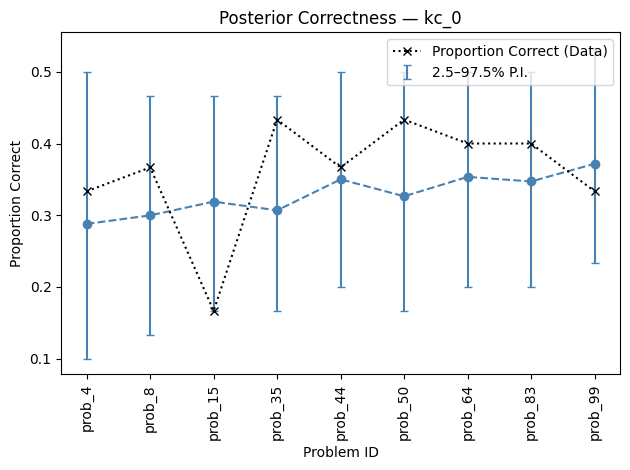

In [31]:
assert isinstance(states_corr, dict)
ax = plot_posterior_correctness(states_corr, data_df,"kc_0", type=PLOT_TYPE, frac=0.3, trajectory=True, offset=0.0)

In [32]:
print_mem_usage(obj=model)

1.7072319999999999 MB


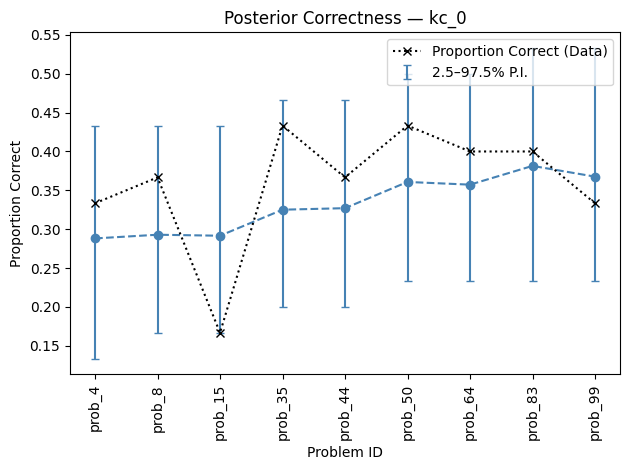

In [48]:
ax2 = plot_posterior_correctness(states_corr_smoothed, data_df,"kc_0", type=PLOT_TYPE, trajectory=True,frac=0.3)

In [34]:
print_mem_usage(obj=model)

1.7072319999999999 MB


## Prediction Summaries

In [49]:
states_corr_summary = model.predict_posterior(output="summary", posterior_draws=states_corr)

In [50]:
states_corr_summary

,kc_id,student_id,problem_id,correct,pKnow_mean,pKnow_std,pKnow_median,pKnow_2.50%,pKnow_97.50%,pCorrectness_mean,pCorrectness_std,pCorrectness_median,pCorrectness_2.50%,pCorrectness_97.50%
0,kc_2,stu_0,prob_0,0,0.051264,0.054749,0.033988,0.000020,0.193617,0.231693,0.041694,0.221817,0.175923,0.336364
1,kc_2,stu_0,prob_1,0,0.020360,0.008634,0.018859,0.008406,0.041504,0.208698,0.014674,0.208456,0.180675,0.238687
2,kc_2,stu_0,prob_2,0,0.017787,0.006542,0.016943,0.007573,0.032689,0.206878,0.014634,0.206761,0.178590,0.236211
3,kc_2,stu_0,prob_5,1,0.017482,0.006561,0.016592,0.007215,0.032548,0.206668,0.014701,0.206547,0.178375,0.236217
4,kc_2,stu_0,prob_12,1,0.084972,0.029991,0.081716,0.036489,0.150500,0.257370,0.022455,0.255942,0.217413,0.304078
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,kc_0,stu_29,prob_83,1,0.055932,0.022786,0.052240,0.021932,0.109832,0.223500,0.416643,0.000000,0.000000,1.000000
2996,kc_0,stu_29,prob_88,0,0.222369,0.073987,0.215243,0.097959,0.387118,0.330750,0.470542,0.000000,0.000000,1.000000
2997,kc_0,stu_29,prob_96,1,0.074800,0.032378,0.069235,0.028069,0.152816,0.216250,0.411738,0.000000,0.000000,1.000000
2998,kc_0,stu_29,prob_97,0,0.271253,0.089494,0.263049,0.118787,0.467091,0.357500,0.479324,0.000000,0.000000,1.000000


In [45]:
states_corr_smoothed_summary = model.predict_smoothed_posterior(output="summary", posterior_draws=states_corr_smoothed)

In [46]:
states_corr_smoothed_summary

,kc_id,student_id,problem_id,correct,pKnow_mean,pKnow_std,pKnow_median,pKnow_2.50%,pKnow_97.50%
0,kc_2,stu_0,prob_0,0,0.003479,0.011059,0.000309,1.729448e-08,0.028221
1,kc_2,stu_0,prob_1,0,0.006995,0.014337,0.001800,1.958412e-07,0.041509
2,kc_2,stu_0,prob_2,0,0.038671,0.040986,0.025852,4.395067e-06,0.142143
3,kc_2,stu_0,prob_5,1,0.402394,0.179130,0.439477,5.996975e-02,0.662612
4,kc_2,stu_0,prob_12,1,0.478057,0.217355,0.526861,6.275692e-02,0.779535
...,...,...,...,...,...,...,...,...,...
2995,kc_0,stu_29,prob_83,1,0.055344,0.038346,0.045260,1.153066e-02,0.155756
2996,kc_0,stu_29,prob_88,0,0.036175,0.027526,0.028558,6.297173e-03,0.107715
2997,kc_0,stu_29,prob_96,1,0.049452,0.032922,0.041013,1.128429e-02,0.134985
2998,kc_0,stu_29,prob_97,0,0.019616,0.015451,0.015256,3.344800e-03,0.060764


In [43]:
states_corr['kc_2']

,chain__,iter__,draw__,kc_id,student_id,problem_id,correct,pKnow,pCorrectness
0,1.0,1.0,1.0,kc_2,stu_0,prob_0,0,0.077105,0.221180
1,1.0,1.0,1.0,kc_2,stu_0,prob_1,0,0.024717,0.181565
2,1.0,1.0,1.0,kc_2,stu_0,prob_2,0,0.019788,0.177837
3,1.0,1.0,1.0,kc_2,stu_0,prob_5,1,0.019348,0.177505
4,1.0,1.0,1.0,kc_2,stu_0,prob_12,1,0.106295,0.243253
...,...,...,...,...,...,...,...,...,...
5159995,4.0,1000.0,4000.0,kc_2,stu_29,prob_87,0,0.021166,0.217523
5159996,4.0,1000.0,4000.0,kc_2,stu_29,prob_89,0,0.008749,0.208448
5159997,4.0,1000.0,4000.0,kc_2,stu_29,prob_92,1,0.007757,0.207723
5159998,4.0,1000.0,4000.0,kc_2,stu_29,prob_94,0,0.039291,0.230771
